# Feature-based Analysis
This analysis is independent of classes. All objects are considered regarding some specific features. This experiment aims at distinguish the relation between features and GP calibration performance.

In [6]:
from datasets import load_dataset
from data_processing import _select_usable_examples, process_one_obj_one_band_train_heldout
from singleGP_model import fit_basic_gp
from evaluation_metrics import (
    evaluate_heldout_metrics,
)
from feature_extraction import (
    make_feature_record_from_gp_split,
    build_feature_table,
    save_feature_table_csv,
    load_feature_table_csv,
    add_quantile_groups,
    summarize_metrics_by_group,
    get_object_band_lightcurve,
    build_records_lookup,
    save_lightcurve_records_csv,
    load_lightcurve_records_csv,
    screen_features_by_spearman,
)
from visualization import(
    plot_metric_by_feature_group,
    plot_feature_vs_metric_scatter,
    plot_object_band_lightcurve,
)

import numpy as np 
import matplotlib.pyplot as plt
dset_plasticc = load_dataset(
    "MultimodalUniverse/plasticc",
    streaming=True,
    split="train",
).with_format("numpy")

## Features Extraction

In [2]:
selected_examples, scanned_examples = _select_usable_examples(
    iter(dset_plasticc),
    target_band="r",
    n_objects=500,
    max_examples_to_scan=1000,
    min_points=8,
)

In [3]:
records = []

for object_idx, example in enumerate(selected_examples):
    train_data, heldout_data = process_one_obj_one_band_train_heldout(
        example,
        target_band="r",
        align_peak=True,
        peak_alignment="target_abs_peak",
        peak_mode="absolute",
        force_peak_in_train=True,
        subtract_background=False,
        scale_mode="local_peak",
        min_points=8,
        heldout_fraction=0.2,
        min_train_points=5,
        min_heldout_points=1,
        random_state=object_idx,
    )

    if train_data is None or heldout_data is None:
        continue

    gp = fit_basic_gp(
        train_data,
        kernel_type="matern",
        n_restarts_optimizer=0,
    )

    metrics = evaluate_heldout_metrics(
        gp,
        heldout_data,
        train_data=train_data,
        object_data=example,
        evaluate_raw_metrics=False,    # compute the normalized-space metrics
    )

    records.append(
        make_feature_record_from_gp_split(train_data, heldout_data, metrics)
    )

df = build_feature_table(records)

/Users/green/Downloads/multi_outputGP/.venv/lib/python3.13/site-packages/sklearn/gaussian_process/kernels.py:440: ConvergenceWarning: The optimal value found for dimension 0 of parameter k2__length_scale is close to the specified lower bound 0.05. Decreasing the bound and calling fit again may find a better value.
  warnings.warn(
/Users/green/Downloads/multi_outputGP/.venv/lib/python3.13/site-packages/sklearn/gaussian_process/kernels.py:440: ConvergenceWarning: The optimal value found for dimension 0 of parameter k2__length_scale is close to the specified lower bound 0.05. Decreasing the bound and calling fit again may find a better value.
  warnings.warn(
/Users/green/Downloads/multi_outputGP/.venv/lib/python3.13/site-packages/sklearn/gaussian_process/kernels.py:440: ConvergenceWarning: The optimal value found for dimension 0 of parameter k2__length_scale is close to the specified lower bound 0.05. Decreasing the bound and calling fit again may find a better value.
  warnings.warn(
/

In [4]:
df["z_error"] = df["z_std"] - 1.0
df["coverage_1sigma_error"] = df["coverage_1sigma"] - 0.6827
df["coverage_2sigma_error"] = df["coverage_2sigma"] - 0.9545
df["coverage_3sigma_error"] = df["coverage_3sigma"] - 0.9973
save_feature_table_csv(df, "singleGP_feature_table.csv")
save_lightcurve_records_csv(records, "singleGP_lightcurve_records.csv")


PosixPath('singleGP_lightcurve_records.csv')

Group objects into quantiles and plot mean performance.

In [2]:
df = load_feature_table_csv("singleGP_feature_table.csv")
records = load_lightcurve_records_csv("singleGP_lightcurve_records.csv")

In [ ]:
df = add_quantile_groups(
    df,
    columns=["mean_abs_slope", "noise_to_signal", "median_crossing_rate"],
    q=10
)

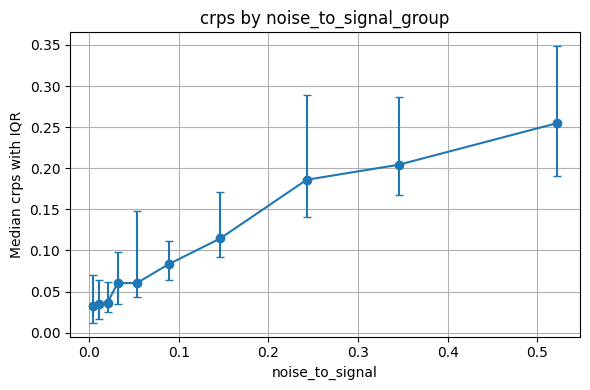

In [ ]:
summary = summarize_metrics_by_group(
    df,
    group_col="noise_to_signal_group",
    metric_cols=["rmse", "nlpd", "crps", "z_error", "ks_pit"],
)
plot_metric_by_feature_group(
    summary,
    group_col="noise_to_signal_group",
    feature_col="noise_to_signal",
    metric_col="crps",
)

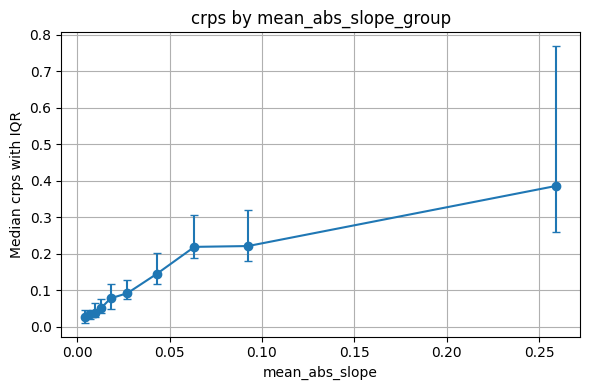

In [7]:
summary = summarize_metrics_by_group(
    df,
    group_col="mean_abs_slope_group",
    metric_cols=["rmse", "nlpd", "crps", "z_error", "ks_pit"],
)
plot_metric_by_feature_group(
    summary,
    group_col="mean_abs_slope_group",
    feature_col="mean_abs_slope",
    metric_col="crps",
)

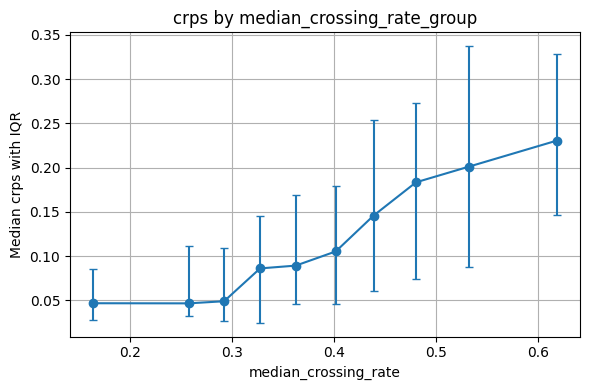

In [8]:
summary = summarize_metrics_by_group(
    df,
    group_col="median_crossing_rate_group",
    metric_cols=["rmse", "nlpd", "crps", "z_error", "ks_pit"],
)
plot_metric_by_feature_group(
    summary,
    group_col="median_crossing_rate_group",
    feature_col="median_crossing_rate",
    metric_col="crps",
)

In [ ]:
outlier = df.loc[df["total_variation"].idxmax()]
print(outlier)

object_id                     297005
obj_type                     M-dwarf
band                               r
t_peak                   60195.28125
flux_scale                  3.738881
                            ...     
coverage_2sigma_error      -0.409045
coverage_3sigma_error      -0.451845
total_variation_group           high
peak_snr_group                  high
max_train_gap_group           medium
Name: 431, Length: 81, dtype: object


In [11]:
cols = [
    "object_id", "obj_type", "band",
    "total_variation", "z_error", "z_std",
    "rmse", "nlpd", "crps", "ks_pit",
    "flux_scale", "flux_range", "flux_range_robust",
    "peak_snr", "noise_to_signal",
    "n_train", "max_train_gap",
    "median_train_cadence",
    "outside_train_frac",
]
print(outlier[cols])

object_id                    297005
obj_type                    M-dwarf
band                              r
total_variation         1487.000945
z_error                   13.135109
z_std                     14.135109
rmse                     145.042136
nlpd                     104.013326
crps                      90.008516
ks_pit                     0.363636
flux_scale                 3.738881
flux_range               719.467768
flux_range_robust          1.423997
peak_snr                2137.782189
noise_to_signal            0.336102
n_train                          41
max_train_gap            245.195323
median_train_cadence       8.884761
outside_train_frac         0.090909
Name: 431, dtype: object


In [6]:
from feature_extraction import summarize_feature_bins

feature = "flat_fraction"

summary = summarize_feature_bins(
    df,
    feature=feature,
    metric_cols=["crps", "rmse", "nlpd", "z_std", "ks_pit"],
    q=20,
)

summary[[
    f"{feature}_group",
    "n_rows",
    "n_objects",
    f"{feature}_mean",
    "crps_mean",
    "crps_std",
    "crps_median",
]]

,flat_fraction_group,n_rows,n_objects,flat_fraction_mean,crps_mean,crps_std,crps_median
0,"(-0.001, 0.0399]",25,25,0.009943,0.164987,0.128679,0.136371
1,"(0.0399, 0.0797]",25,25,0.056018,0.276102,0.216876,0.247703
2,"(0.0797, 0.115]",34,34,0.097885,0.261389,0.208784,0.205392
3,"(0.115, 0.143]",17,17,0.128522,0.221345,0.119867,0.190639
4,"(0.143, 0.206]",24,24,0.169188,0.186607,0.062455,0.185365
5,"(0.206, 0.269]",26,26,0.237619,0.210353,0.172130,0.171736
6,"(0.269, 0.346]",28,28,0.315981,0.194892,0.277236,0.105935
7,"(0.346, 0.444]",21,21,0.394576,0.096384,0.076898,0.082731
8,"(0.444, 0.522]",26,26,0.485745,0.155986,0.184809,0.093526
9,"(0.522, 0.6]",26,26,0.569569,0.174952,0.189892,0.113333


(<Figure size 600x400 with 1 Axes>,
 <Axes: title={'center': 'crps by flat_fraction_group'}, xlabel='flat_fraction', ylabel='Mean crps'>)

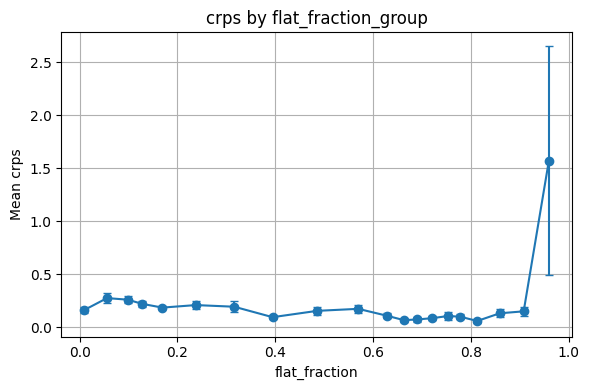

In [8]:
plot_metric_by_feature_group(
    summary,
    group_col="flat_fraction_group",
    feature_col="flat_fraction",
    metric_col="crps",
)

Some objects with extremely large flat regions correspond to bad CRPS.

In [11]:
feature = "mean_abs_slope"

summary = summarize_feature_bins(
    df,
    feature=feature,
    metric_cols=["crps", "rmse", "nlpd", "z_std", "ks_pit"],
    q=20,
)

summary[[
    f"{feature}_group",
    "n_rows",
    "n_objects",
    f"{feature}_mean",
    "crps_mean",
    "crps_std",
    "crps_median",
]]

,mean_abs_slope_group,n_rows,n_objects,mean_abs_slope_mean,crps_mean,crps_std,crps_median
0,"(0.00068, 0.00429]",25,25,0.003362,0.021634,0.016432,0.017310
1,"(0.00429, 0.00569]",25,25,0.004940,0.071468,0.130194,0.038013
2,"(0.00569, 0.00687]",25,25,0.006277,0.036043,0.031122,0.032797
3,"(0.00687, 0.00794]",25,25,0.007357,0.047840,0.037529,0.035623
4,"(0.00794, 0.00976]",25,25,0.008713,0.072272,0.115060,0.035164
5,"(0.00976, 0.0108]",25,25,0.010223,0.073468,0.144931,0.043441
6,"(0.0108, 0.0132]",25,25,0.012230,0.076714,0.057057,0.061221
7,"(0.0132, 0.015]",25,25,0.014018,0.052924,0.019961,0.049098
8,"(0.015, 0.0183]",25,25,0.016770,0.110791,0.186279,0.060488
9,"(0.0183, 0.0217]",25,25,0.019501,0.104568,0.090301,0.093965


### Attention! Check the object corresponding the extreme value 2.398!!!

In [11]:
row_idx = df["mean_abs_slope"].idxmax()
obj_id = df.loc[row_idx, "object_id"]   # get row_idx from column "object_id"
band = df.loc[row_idx, "band"]

<Axes: title={'center': 'object_id=297005, band=r'}, xlabel='time (raw)', ylabel='normalized flux'>

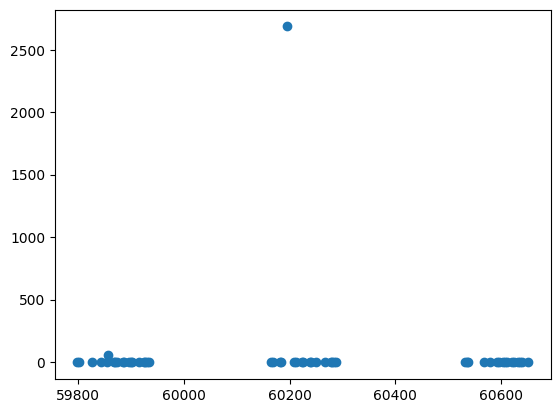

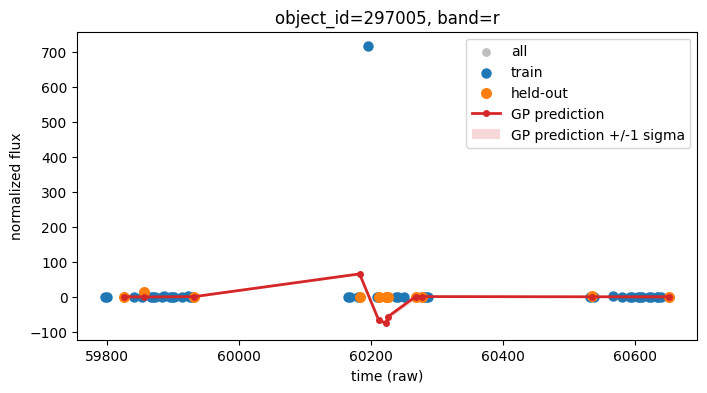

In [12]:
result = get_object_band_lightcurve(records, obj_id, band)

plt.scatter(result["t_all"], result["flux_all"])
plot_object_band_lightcurve(result, normalize=True)

In [13]:
print(result["flux_train"])
print(result["t_train"])

[-8.96431983e-01  3.05752993e-01 -9.34382975e-01 -2.53143311e+00
 -2.33514994e-01  1.57428205e+00 -2.24849296e+00  1.02870202e+00
  3.94398093e+00  7.20819980e-02  1.39856994e+00  7.06727028e-01
 -1.71991706e+00  2.25312400e+00  2.26163998e-01  5.60243011e-01
  1.70655894e+00  6.61897004e-01  1.96202898e+00  2.68643335e+03
  3.90033990e-01  4.95436013e-01  1.01806295e+00  1.58442700e+00
  1.02204895e+00  8.61769974e-01  6.81963980e-01 -5.19127011e-01
 -1.14282799e+00  2.23543906e+00 -2.50119001e-01  6.03358984e-01
 -3.57107210e+00 -5.69993973e-01  9.96761978e-01 -8.40403020e-01
  1.14615405e+00  1.20976901e+00  5.41375995e-01 -1.64849997e+00
 -1.85346496e+00]
[59798.32030056 59801.35548081 59842.24607997 59854.14842924
 59867.10939241 59870.10545903 59873.09765119 59884.17577311
 59887.28515854 59896.12891475 59899.15234245 59902.13671189
 59914.0507768  59924.10546863 59927.10546507 59930.12499986
 60165.30468696 60168.28906331 60181.41015595 60195.28125
 60209.17968784 60238.3203125 

the high feature value is mainly caused by a single extreme flux point rather than by a smoothly varying light curve. Therefore, this case should be interpreted as an outlier-dominated example. The apparent downward GP curve near the peak is also partly a plotting artefact, since the red line connects GP predictions only at the held-out time points, rather than showing the full latent GP prediction over a dense time grid.

This object can be discarded.

<Axes: title={'center': 'object_id=32014077, band=r'}, xlabel='time (raw)', ylabel='normalized flux'>

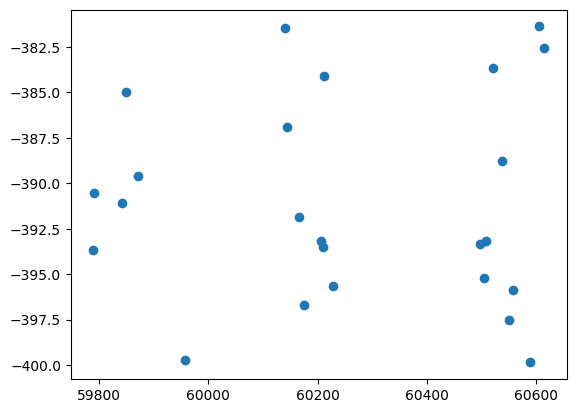

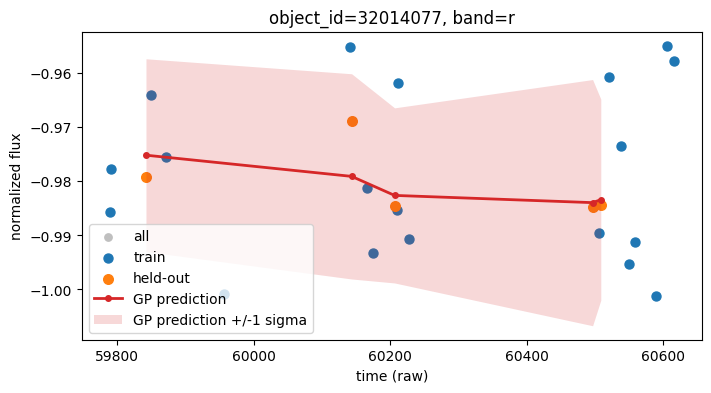

In [10]:
row_idx2 = df["mean_abs_slope"].idxmin()
obj_id2 = df.loc[row_idx2, "object_id"]   # get row_idx from column "object_id"
band2 = df.loc[row_idx2, "band"]
result2 = get_object_band_lightcurve(records, obj_id2, band2)

plt.scatter(result["t_all"], result2["flux_all"])
plot_object_band_lightcurve(result2, normalize=True)

Small slope is hard to predict...

## Outdated Plots
In the following plots, the mean is shown as the central value, while the error bars represents one standard deviation.

(<Figure size 600x400 with 1 Axes>,
 <Axes: title={'center': 'crps by mean_abs_slope_group'}, xlabel='mean_abs_slope', ylabel='Mean crps'>)

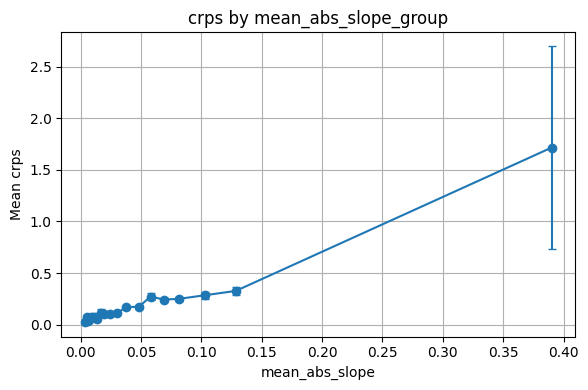

In [12]:
plot_metric_by_feature_group(
    summary,
    group_col=f"{feature}_group",
    feature_col=feature,
    metric_col="crps",
)

In [10]:
feature_cols = [
    "n_train",
    "train_time_span",
    "median_train_cadence",
    "max_train_gap",
    "gap_90_train",
    "outside_train_frac",
    "nearest_train_distance_mean",
    "distance_peak_to_nearest_train",
    "fraction_train_near_peak",
    "flux_range_robust",
    "flat_fraction",
    "width_50_pos",
    "total_variation",
    "mean_abs_slope",
    "median_crossing_rate",
    "peak_snr",
    "noise_to_signal",
    "log_total_variation",
    "log_peak_snr",
    "log_mean_abs_slope",
]

screen_z = screen_features_by_spearman(df, feature_cols, "z_error")
screen_abs_z = screen_features_by_spearman(df, feature_cols, "crps")
screen_ks = screen_features_by_spearman(df, feature_cols, "ks_pit")

print(screen_z.head(15))
print(screen_abs_z.head(15))
print(screen_ks.head(15))

                        feature   target  spearman_rho  abs_spearman_rho    n
9                 flat_fraction  z_error     -0.344680          0.344680  500
10                 width_50_pos  z_error      0.298760          0.298760  491
7      fraction_train_near_peak  z_error     -0.233706          0.233706  500
14                     peak_snr  z_error     -0.205592          0.205592  500
8             flux_range_robust  z_error      0.182877          0.182877  500
6   nearest_train_distance_mean  z_error     -0.163378          0.163378  500
0                       n_train  z_error      0.154023          0.154023  500
12               mean_abs_slope  z_error      0.152024          0.152024  500
11              total_variation  z_error      0.134631          0.134631  500
4                  gap_90_train  z_error     -0.131754          0.131754  500
2          median_train_cadence  z_error     -0.130953          0.130953  500
15              noise_to_signal  z_error      0.100309          

In [11]:
roughness_cols = [
    "mean_abs_slope",
    "total_variation",
    "flux_range_robust",
    "median_crossing_rate",
    "noise_to_signal",
    "peak_snr",
]

df[roughness_cols].corr(method="spearman")

,mean_abs_slope,total_variation,flux_range_robust,median_crossing_rate,noise_to_signal,peak_snr
mean_abs_slope,1.000000,0.915012,0.808970,0.500441,0.795507,-0.538702
total_variation,0.915012,1.000000,0.779933,0.451011,0.738689,-0.395663
flux_range_robust,0.808970,0.779933,1.000000,0.367877,0.810778,-0.641376
median_crossing_rate,0.500441,0.451011,0.367877,1.000000,0.375787,-0.209241
noise_to_signal,0.795507,0.738689,0.810778,0.375787,1.000000,-0.817007
peak_snr,-0.538702,-0.395663,-0.641376,-0.209241,-0.817007,1.000000


In [15]:
sampling_cols = [
    "flat_fraction",
    "width_50_pos",
    "fraction_train_near_peak",
]

df[sampling_cols].corr(method="spearman")

,flat_fraction,width_50_pos,fraction_train_near_peak
flat_fraction,1.000000,-0.509907,-0.053970
width_50_pos,-0.509907,1.000000,0.129884
fraction_train_near_peak,-0.053970,0.129884,1.000000


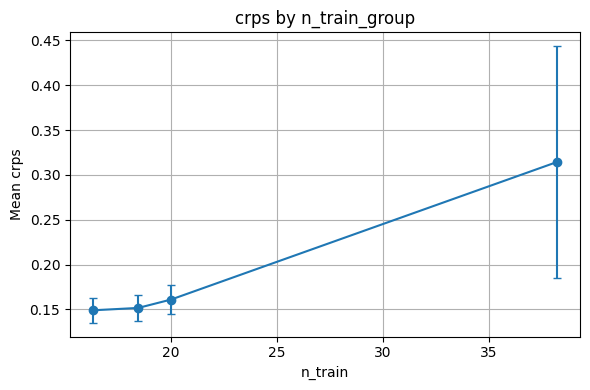

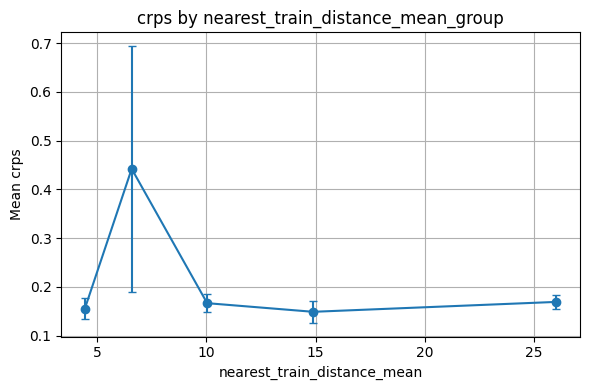

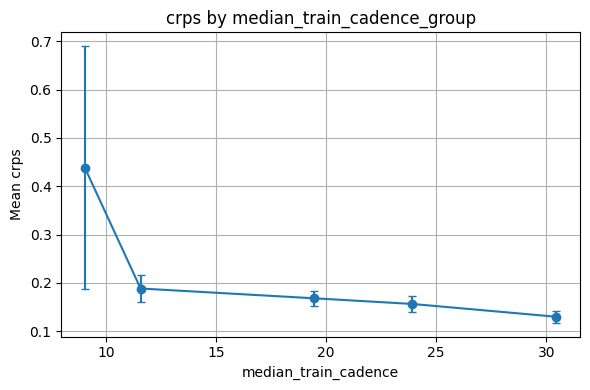

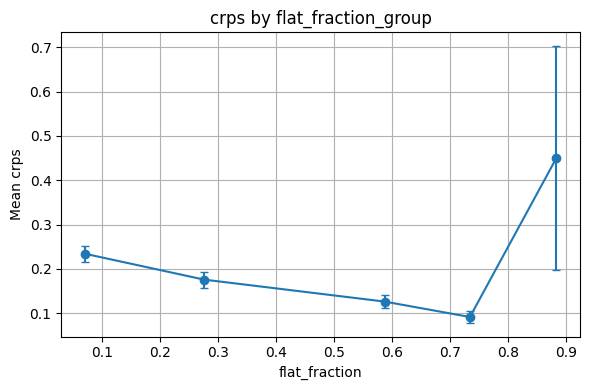

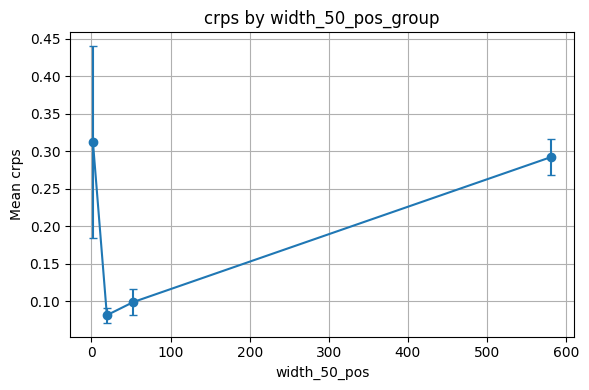

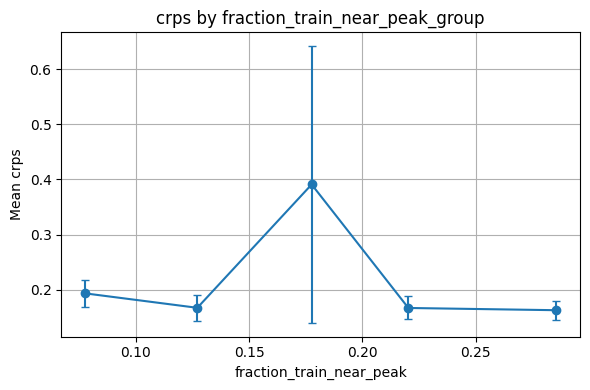

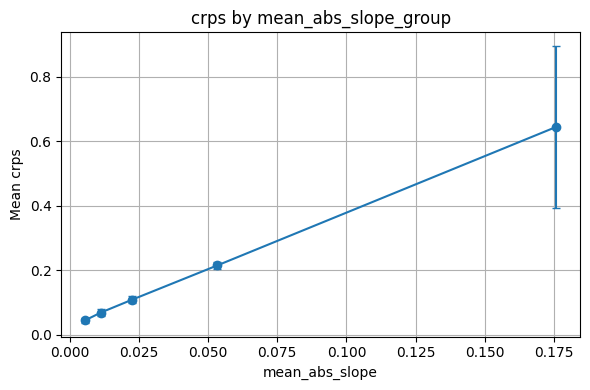

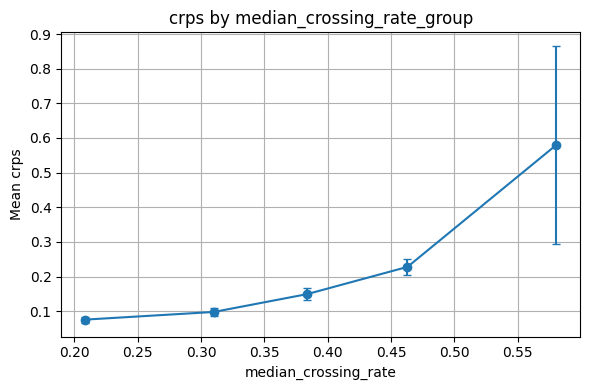

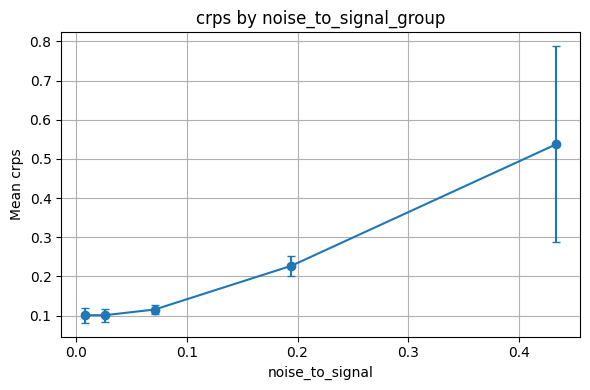

In [16]:
reduced_features = [
    # sampling geometry
    "n_train",
    "nearest_train_distance_mean",
    "median_train_cadence",

    # morphology / transient shape
    "flat_fraction",
    "width_50_pos",
    "fraction_train_near_peak",

    # roughness / noise
    "mean_abs_slope",
    "median_crossing_rate",
    "noise_to_signal",
]

for feature in reduced_features:
    df_grouped = add_quantile_groups(df, [feature], q=5)
    summary = summarize_metrics_by_group(
        df_grouped,
        group_col=f"{feature}_group",
        metric_cols=["z_error", "crps", "ks_pit"],
    )
    plot_metric_by_feature_group(
        summary,
        group_col=f"{feature}_group",
        feature_col=feature,
        metric_col="crps",
    )